**Custom Models and Training with TensorFlow**

A Quick Tour of TensorFlow

• Its core is very similar to NumPy, but with GPU support.

• It supports distributed computing (across multiple devices and servers).
• It includes a kind of just-in-time (JIT) compiler that allows it to optimize computations for speed and memory usage. It works by extracting the computation graph from a Python function, then optimizing it (e.g., by pruning unused nodes), and finally running it efficiently (e.g., by automatically running independent operations in parallel).

• Computation graphs can be exported to a portable format, so you can train a TensorFlow model in one environment (e.g., using Python on Linux) and run it in another (e.g., using Java on an Android device).

• It implements autodiff (see Chapter 10 and Appendix D) and provides some
excellent optimizers, such as RMSProp and Nadam (see Chapter 11), so you can
easily minimize all sorts of loss functions.

At the lowest level, each TensorFlow operation (op for short) is implemented using highly efficient C++ code. 

Many operations have multiple implementations called kernels: each kernel is dedicated to a specific device type, such as CPUs, GPUs, or even TPUs (tensor processing units).

In [2]:
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
except Exception:
    pass

# TensorFlow ≥2.4 is required in this notebook
# Earlier 2.x versions will mostly work the same, but with a few bugs
import tensorflow as tf
from tensorflow import keras


# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)
tf.random.set_seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "deep"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

**Using TensorFlow like NumPy**

- TensorFlow’s API revolves around tensors, which flow from operation to operation hence the name TensorFlow.

- A tensor is very similar to a NumPy ndarray: it is usually a multidimensional array, but it can also hold a scalar. 

***Tensors and Operations***

You can create a tensor with tf.constant().

In [3]:
tf.constant([[1., 2., 3.], [4., 5., 6.]])

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

In [4]:
tf.constant(42)

<tf.Tensor: shape=(), dtype=int32, numpy=42>

Just like an ndarray, a tf.Tensor has a shape and a data type (dtype):

In [5]:
t = tf.constant([[1., 2., 3.], [4., 5., 6.]])
t.shape

TensorShape([2, 3])

In [6]:
t.dtype

tf.float32

Indexing works much like in NumPy:

In [7]:
t[:, 1:]

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[2., 3.],
       [5., 6.]], dtype=float32)>

In [8]:
t[..., 1, tf.newaxis]

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[2.],
       [5.]], dtype=float32)>

Most importantly, all sorts of tensor operations are available:

In [9]:
t + 10

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[11., 12., 13.],
       [14., 15., 16.]], dtype=float32)>

In [10]:
tf.square(t)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[ 1.,  4.,  9.],
       [16., 25., 36.]], dtype=float32)>

In [11]:
t @ tf.transpose(t)

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[14., 32.],
       [32., 77.]], dtype=float32)>

You will find all the basic math operations you need (tf.add(), tf.multipl(), tf.square(), tf.exp(), tf.sqrt(), etc.) and most operations that you can find in NumPy (e.g., tf.reshape(), tf.squeeze(), tf.tile()).

Some functions have a different name than in NumPy; for instance, tf.reduce_mean(), tf.reduce_sum(), tf.reduce_max(), and tf.math.log() are the equivalent of np.mean(), np.sum(), np.max() and np.log().

***Keras’ Low-Level API***

The Keras API has its own low-level API, located in keras.backend. It includes functions like square(), exp(), and sqrt().

In tf.keras, these functions generally just call the corresponding TensorFlow operations.

However, they only cover a subset of all functions available in TensorFlow, so in this book we will use the TensorFlow operations directly. Here is as simple example using keras.backend, which is commonly named K for short:

In [12]:
from tensorflow import keras
K = keras.backend
K.square(K.transpose(t)) + 10

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[11., 26.],
       [14., 35.],
       [19., 46.]], dtype=float32)>

***Tensors and Numpy***

Tensors play nice with NumPy: you can create a tensor from a NumPy array, and vice versa. You can even apply TensorFlow operations to NumPy arrays and NumPy operations to tensors:

In [13]:
a = np.array([2., 4., 5.])
tf.constant(a)

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([2., 4., 5.])>

In [14]:
t.numpy() # or np.array(t)

array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)

In [15]:
tf.square(a)

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([ 4., 16., 25.])>

In [16]:
np.square(t)

array([[ 1.,  4.,  9.],
       [16., 25., 36.]], dtype=float32)

*Notice that NumPy uses 64-bit precision by default, while TensorFlow uses 32-bit. This is because 32-bit precision is generally more than enough for neural networks, plus it runs faster and uses less RAM. So when you create a tensor from a NumPy array, make sure to set dtype=tf.float32.*

***Type Conversions***

Type conversions can significantly hurt performance, and they can easily go unnoticed when they are done automatically.

To avoid this, TensorFlow does not perform any type conversions automatically: it just raises an exception if you try to execute an
operation on tensors with incompatible types.

In [18]:
#tf.constant(2.) + tf.constant(40)
#Traceback[...]InvalidArgumentError[...]expected to be a float[...]
#tf.constant(2.) + tf.constant(40., dtype=tf.float64)
#Traceback[...]InvalidArgumentError[...]expected to be a double[...]

This may be a bit annoying at first, but remember that it’s for a good cause! And of course you can use tf.cast() when you really need to convert types:

In [19]:
t2 = tf.constant(40., dtype=tf.float64)
tf.constant(2.0) + tf.cast(t2, tf.float32)

<tf.Tensor: shape=(), dtype=float32, numpy=42.0>

***Variables***

The tf.Tensor values we’ve seen so far are immutable: you cannot modify them. This means that we cannot use regular tensors to implement weights in a neural network, since they need to be tweaked by backpropagation.

In [20]:
v = tf.Variable([[1., 2., 3.], [4., 5., 6.]])
v

<tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

A tf.Variable acts much like a tf.Tensor: you can perform the same operations with it, it plays nicely with NumPy as well, and it is just as picky with types.

It can also be modified in place using the assign() method (or assign_add() or
assign_sub(), which increment or decrement the variable by the given value).

You can also modify individual cells (or slices), by using the cell’s (or slice’s) assign() method (direct item assignment will not work) or by using the scatter_update() or scatter_nd_update() methods:

In [21]:
v.assign(2 * v)
v[0, 1].assign(42)
v[:, 2].assign([0., 1.])
v.scatter_nd_update(indices=[[0, 0], [1, 2]], updates=[100., 200.])

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[100.,  42.,   0.],
       [  8.,  10., 200.]], dtype=float32)>

*In practice you will rarely have to create variables manually, since Keras provides an add_weight() method that will take care of it for you, as we will see. Moreover, model parameters will generally be updated directly by the optimizers, so you will rarely need to update variables manually.*

***Other Data Structures***

TensorFlow supports several other data structures, including the following:

Sparse tensors (tf.SparseTensor): 
Efficiently represent tensors containing mostly zeros. The tf.sparse package contains operations for sparse tensors.

Tensor arrays (tf.TensorArray):
Are lists of tensors. They have a fixed size by default but can optionally be made dynamic. All tensors they contain must have the same shape and data type.

Ragged tensors (tf.RaggedTensor):
Represent static lists of lists of tensors, where every tensor has the same shape and data type. The tf.ragged package contains operations for ragged tensors.

String tensors:
Are regular tensors of type tf.string. These represent byte strings, not Unicode strings, so if you create a string tensor using a Unicode string (e.g., a regular Python 3 string like "café"), then it will get encoded to UTF-8 automatically (e.g., b"caf\xc3\xa9").

Sets:
Are represented as regular tensors (or sparse tensors). For example, tf.constant([[1, 2], [3, 4]]) represents the two sets {1, 2} and {3, 4}.

Queues:
Store tensors across multiple steps. TensorFlow offers various kinds of queues: simple First In, First Out (FIFO) queues (FIFOQueue), queues that can prioritize some items (PriorityQueue), shuffle their items (RandomShuffleQueue), and batch items of different shapes by padding (PaddingFIFOQueue).

With tensors, operations, variables, and various data structures at your disposal, you are now ready to customize your models and training algorithms!

**Customizing Models and Training Algorithms**

***Custom Loss Functions***

Suppose you want to train a regression model, but your training set is a bit noisy. Of course, you start by trying to clean up your dataset by removing or fixing the outliers, but that turns out to be insufficient; the dataset is still noisy.

This is probably a good time to use the Huber loss (introduced in Chapter 10) instead of the good old MSE. The Huber loss is not currently part of the official Keras API, but it is available in tf.keras (just use an instance of the keras.losses.Huber class).

In [22]:
def huber_fn(y_true, y_pred):
    error = y_true - y_pred
    is_small_error = tf.abs(error) < 1
    squared_loss = tf.square(error) / 2
    linear_loss = tf.abs(error) - 0.5
    return tf.where(is_small_error, squared_loss, linear_loss)

*For better performance, you should use a vectorized implementation, as in this example. Moreover, if you want to benefit from TensorFlow’s graph features, you should use only TensorFlow operations.*

Let's start by loading and preparing the California housing dataset. We first load it, then split it into a training set, a validation set and a test set, and finally we scale it:

In [23]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target.reshape(-1, 1), random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

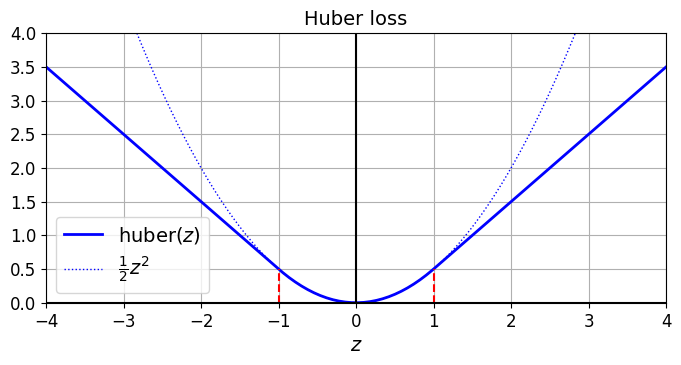

In [24]:
plt.figure(figsize=(8, 3.5))
z = np.linspace(-4, 4, 200)
plt.plot(z, huber_fn(0, z), "b-", linewidth=2, label="huber($z$)")
plt.plot(z, z**2 / 2, "b:", linewidth=1, label=r"$\frac{1}{2}z^2$")
plt.plot([-1, -1], [0, huber_fn(0., -1.)], "r--")
plt.plot([1, 1], [0, huber_fn(0., 1.)], "r--")
plt.gca().axhline(y=0, color='k')
plt.gca().axvline(x=0, color='k')
plt.axis([-4, 4, 0, 4])
plt.grid(True)
plt.xlabel("$z$")
plt.legend(fontsize=14)
plt.title("Huber loss", fontsize=14)
plt.show()

In [27]:
input_shape = X_train.shape[1:]

model = keras.models.Sequential([
    keras.layers.Dense(30, activation="selu", kernel_initializer="lecun_normal",
                       input_shape=input_shape),
    keras.layers.Dense(1),
])

d:\dev\data546\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.compile(loss=huber_fn, optimizer="nadam", metrics=["mae"])

model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 0.5568 - mae: 0.9170 - val_loss: 0.2979 - val_mae: 0.5909
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2140 - mae: 0.5075 - val_loss: 0.2439 - val_mae: 0.5285


***Saving and Loading Models That Contain Custom Components***

Saving a model containing a custom loss function works fine, as Keras saves the name of the function.

Whenever you load it, you’ll need to provide a dictionary that maps the function name to the actual function. More generally, when you load a model containing custom objects, you need to map the names to the objects:

In [30]:
model.save("my_model_with_a_custom_loss.h5")

In [31]:
model = keras.models.load_model("my_model_with_a_custom_loss.h5",
                                custom_objects={"huber_fn": huber_fn})

In [33]:
def create_huber(threshold=1.0):
    def huber_fn(y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) < threshold
        squared_loss = tf.square(error) / 2
        linear_loss = threshold * tf.abs(error) - threshold**2 / 2
        return tf.where(is_small_error, squared_loss, linear_loss)
    return huber_fn
model.compile(loss=create_huber(2.0), optimizer="nadam")

In [35]:
class HuberLoss(keras.losses.Loss):
    def __init__(self, threshold=1.0, **kwargs):
        self.threshold = threshold
        super().__init__(**kwargs)
    def call(self, y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) < self.threshold
        squared_loss = tf.square(error) / 2
        linear_loss = self.threshold * tf.abs(error) - self.threshold**2 / 2
        return tf.where(is_small_error, squared_loss, linear_loss)
    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "threshold": self.threshold}

*The Keras API currently only specifies how to use subclassing to define layers, models, callbacks, and regularizers. If you build other components (such as losses, metrics, initializers, or constraints) using subclassing, they may not be portable to other Keras implementations. It’s likely that the Keras API will be updated to specify subclassing for all these components as well.*

Let’s walk through this code:

The constructor accepts **kwargs and passes them to the parent constructor, which handles standard hyperparameters: the name of the loss and the reduction algorithm to use to aggregate the individual instance losses. By default, it is "sum_over_batch_size", which means that the loss will be the sum of the instance losses, weighted by the sample weights, if any, and divided by the batch size (not by the sum of weights, so this is not the weighted mean).5 Other possible values are "sum" and "none".

The call() method takes the labels and predictions, computes all the instance losses, and returns them.

The get_config() method returns a dictionary mapping each hyperparameter name to its value. It first calls the parent class’s get_config() method, then adds the new hyperparameters to this dictionary (note that the convenient {**x} syntax was added in Python 3.5).

In [36]:
model.compile(loss=HuberLoss(2.), optimizer="nadam")

In [38]:

model = keras.models.Sequential([
    keras.layers.Dense(30, activation="selu", kernel_initializer="lecun_normal",
                       input_shape=input_shape),
    keras.layers.Dense(1),
])

In [41]:
model.compile(loss=HuberLoss(2.), optimizer="nadam", metrics=["mae"])


In [42]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - loss: 0.9163 - mae: 1.0101 - val_loss: 0.4918 - val_mae: 0.6454
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2564 - mae: 0.5282 - val_loss: 0.3855 - val_mae: 0.5721


When you save the model, the threshold will be saved along with it; and when you load the model, you just need to map the class name to the class itself:

In [43]:

model.save("my_model_with_a_custom_loss_class.h5")

In [44]:

model = keras.models.load_model("my_model_with_a_custom_loss_class.h5",
                                custom_objects={"HuberLoss": HuberLoss})

**Custom Activation Functions, Initializers, Regularizers, and Constraints**

Most Keras functionalities, such as losses, regularizers, constraints, initializers, metrics, activation functions, layers, and even full models, can be customized in very much the same way.

Most of the time, you will just need to write a simple function with the appropriate inputs and outputs.

Here are examples of a custom activation function (equivalent to keras.activations.softplus() or tf.nn.softplus()), a custom Glorot initializer (equivalent to keras.initializers.glorot_normal()), a custom ℓ1 regularizer (equivalent to keras.regularizers.l1(0.01)), and a custom constraint that ensures weights are all positive (equivalent to keras.con straints.nonneg() or tf.nn.relu()):

In [47]:
def my_softplus(z): # return value is just tf.nn.softplus(z)
    return tf.math.log(tf.exp(z) + 1.0)

def my_glorot_initializer(shape, dtype=tf.float32):
    stddev = tf.sqrt(2. / (shape[0] + shape[1]))
    return tf.random.normal(shape, stddev=stddev, dtype=dtype)

def my_l1_regularizer(weights):
    return tf.reduce_sum(tf.abs(0.01 * weights))

def my_positive_weights(weights): # return value is just tf.nn.relu(weights)
    return tf.where(weights < 0., tf.zeros_like(weights), weights)

As you can see, the arguments depend on the type of custom function. These custom functions can then be used normally; for example:

In [48]:
layer = keras.layers.Dense(30, activation=my_softplus,
                        kernel_initializer=my_glorot_initializer,
                        kernel_regularizer=my_l1_regularizer,
                        kernel_constraint=my_positive_weights)

The activation function will be applied to the output of this Dense layer, and its result will be passed on to the next layer.

The layer’s weights will be initialized using the value returned by the initializer. At each training step the weights will be passed to the regularization function to compute the regularization loss, which will be added to the main loss to get the final loss used for training.

Finally, the constraint function will be called after each training step, and the layer’s weights will be replaced by the constrained weights.

If a function has hyperparameters that need to be saved along with the model, then you will want to subclass the appropriate class, such as keras.regularizers.Regularizer, keras.constraints.Constraint, keras.initializers.Initializer, or keras.layers.Layer (for any layer, including activation functions).

Much like we did for the custom loss, here is a simple class for ℓ1 regularization that saves its factor hyperparameter (this time we do not need to call the parent constructor or the get_config() method, as they are not defined by the parent class):

In [49]:
class MyL1Regularizer(keras.regularizers.Regularizer):
    def __init__(self, factor):
        self.factor = factor
    def __call__(self, weights):
        return tf.reduce_sum(tf.abs(self.factor * weights))
    def get_config(self):
        return {"factor": self.factor}

**Custom Metrics**

Losses and metrics are conceptually not the same thing: losses (e.g., cross entropy) are used by Gradient Descent to train a model, so they must be differentiable (at least where they are evaluated), and their gradients should not be 0 everywhere.

In most cases, defining a custom metric function is exactly the same as
defining a custom loss function. In fact, we could even use the Huber loss function we created earlier as a metric;6 it would work just fine (and persistence would also work the same way, in this case only saving the name of the function, "huber_fn"):

In [50]:
model.compile(loss="mse", optimizer="nadam", metrics=[create_huber(2.0)])

Suppose the model made five positive predictions in the first batch, four of which were correct: that’s 80% precision. Then suppose the model made three positive predictions in the second batch, but they were all incorrect: that’s 0% precision for the second batch. If you just compute the mean of these two precisions, you get 40%.

In [51]:
precision = keras.metrics.Precision()
precision([0, 1, 1, 1, 0, 1, 0, 1], [1, 1, 0, 1, 0, 1, 0, 1])

<tf.Tensor: shape=(), dtype=float32, numpy=0.800000011920929>

In [52]:
precision([0, 1, 0, 0, 1, 0, 1, 1], [1, 0, 1, 1, 0, 0, 0, 0])

<tf.Tensor: shape=(), dtype=float32, numpy=0.5>

In this example, we created a Precision object, then we used it like a function, passing it the labels and predictions for the first batch, then for the second batch (note that we could also have passed sample weights).

We used the same number of true and false positives as in the example we just discussed. After the first batch, it returns a precision of 80%; then after the second batch, it returns 50% (which is the overall precision so far, not the second batch’s precision).

This is called a streaming metric (or stateful metric), as it is gradually updated, batch after batch.

At any point, we can call the result() method to get the current value of the metric.

In [53]:
precision.result()


<tf.Tensor: shape=(), dtype=float32, numpy=0.5>

In [54]:
precision.variables

[<Variable path=precision/true_positives, shape=(1,), dtype=float32, value=[4.]>,
 <Variable path=precision/false_positives, shape=(1,), dtype=float32, value=[4.]>]

Creating a streaming metric:

In [57]:

class HuberMetric(keras.metrics.Metric):
    def __init__(self, threshold=1.0, **kwargs):
        super().__init__(**kwargs) # handles base args (e.g., dtype)
        self.threshold = threshold
        self.huber_fn = create_huber(threshold)
        self.total = self.add_weight("total", initializer="zeros")
        self.count = self.add_weight("count", initializer="zeros")
    def update_state(self, y_true, y_pred, sample_weight=None):
        metric = self.huber_fn(y_true, y_pred)
        self.total.assign_add(tf.reduce_sum(metric))
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))
    def result(self):
        return self.total / self.count
    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "threshold": self.threshold}

The constructor uses the add_weight() method to create the variables needed t keep track of the metric’s state over multiple batches—in this case, the sum of all Huber losses (total) and the number of instances seen so far (count). You could just create variables manually if you preferred. Keras tracks any tf.Variable that is set as an attribute (and more generally, any “trackable” object, such as layers or models).

The update_state() method is called when you use an instance of this class as a function (as we did with the Precision object). It updates the variables, given the labels and predictions for one batch (and sample weights, but in this case we ignore them).

The result() method computes and returns the final result, in this case the mean Huber metric over all instances. When you use the metric as a function, the update_state() method gets called first, then the result() method is called, and its output is returned.

We also implement the get_config() method to ensure the threshold gets saved along with the model.

The default implementation of the reset_states() method resets all variables to 0.0 (but you can override it if needed).

***Custom Layers***

First, some layers have no weights, such as keras.layers.Flatten or keras.layers.ReLU.

If you want to create a custom layer without any weights, the simplest option is to write a function and wrap it in a keras.layers.Lambda layer. For example, the following layer will apply the exponential function to its inputs:

In [58]:
exponential_layer = keras.layers.Lambda(lambda x: tf.exp(x))

This custom layer can then be used like any other layer, using the Sequential API, the Functional API, or the Subclassing API.

You can also use it as an activation function (or you could use activation=tf.exp, activation=keras.activations.exponential, or simply activation="exponential").

The exponential layer is sometimes used in the output layer of a regression model when the values to predict have very different scales (e.g., 0.001, 10., 1,000.).

In [59]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [60]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=input_shape),
    keras.layers.Dense(1),
    exponential_layer
])
model.compile(loss="mse", optimizer="sgd")
model.fit(X_train_scaled, y_train, epochs=5,
          validation_data=(X_valid_scaled, y_valid))
model.evaluate(X_test_scaled, y_test)

d:\dev\data546\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 0.6912 - val_loss: 0.4054
Epoch 2/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4254 - val_loss: 0.3796
Epoch 3/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4062 - val_loss: 0.3712
Epoch 4/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3938 - val_loss: 0.3642
Epoch 5/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4143 - val_loss: 0.3707
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3895


0.3894713222980499

To build a custom stateful layer (i.e., a layer with weights), you need to create a subclass of the keras.layers.Layer class. The following class implements a simplified version of the Dense layer:

In [61]:
class MyDense(keras.layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = keras.activations.get(activation)

    def build(self, batch_input_shape):
        self.kernel = self.add_weight(
            name="kernel", shape=[batch_input_shape[-1], self.units],
            initializer="glorot_normal")
        self.bias = self.add_weight(
            name="bias", shape=[self.units], initializer="zeros")
        super().build(batch_input_shape) # must be at the end

    def call(self, X):
        return self.activation(X @ self.kernel + self.bias)

    def compute_output_shape(self, batch_input_shape):
        return tf.TensorShape(batch_input_shape.as_list()[:-1] + [self.units])

    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "units": self.units,
                "activation": keras.activations.serialize(self.activation)}

In [62]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [63]:
model = keras.models.Sequential([
    MyDense(30, activation="relu", input_shape=input_shape),
    MyDense(1)
])

C:\Users\huysi\AppData\Local\Temp\ipykernel_22420\1007238509.py:3: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


AttributeError: Exception encountered when calling MyDense.call().

[1m'tuple' object has no attribute 'as_list'[0m

Arguments received by MyDense.call():
  • args=('<KerasTensor shape=(None, 8), dtype=float32, sparse=False, ragged=False, name=keras_tensor>',)
  • kwargs=<class 'inspect._empty'>

In [64]:
model.compile(loss="mse", optimizer="nadam")
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))
model.evaluate(X_test_scaled, y_test)

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - loss: 0.3752 - val_loss: 0.3462
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3660 - val_loss: 0.3399
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3578


0.3578355610370636

The constructor takes all the hyperparameters as arguments (in this example, units and activation), and importantly it also takes a **kwargs argument. It calls the parent constructor, passing it the kwargs: this takes care of standard arguments such as input_shape, trainable, and name. Then it saves the hyperparameters as attributes, converting the activation argument to the appropriate activation function using the keras.activations.get() function (it accepts functions, standard strings like "relu" or "selu", or simply None).

The build() method’s role is to create the layer’s variables by calling the add_weight() method for each weight. The build() method is called the first time the layer is used. At that point, Keras will know the shape of this layer’s inputs, and it will pass it to the build() method,9 which is often necessary to create some of the weights. For example, we need to know the number of neurons in the previous layer in order to create the connection weights matrix (i.e., the "kernel"): this corresponds to the size of the last dimension of the inputs. At the end of the build() method (and only at the end), you must call the parent’s build() method: this tells Keras that the layer is built (it just sets self.built=True).

The call() method performs the desired operations. In this case, we compute the matrix multiplication of the inputs X and the layer’s kernel, we add the bias vector, and we apply the activation function to the result, and this gives us the output of the layer.

The compute_output_shape() method simply returns the shape of this layer’s outputs. In this case, it is the same shape as the inputs, except the last dimension is replaced with the number of neurons in the layer. Note that in tf.keras, shapes are instances of the tf.TensorShape class, which you can convert to Python lists using as_list().

The get_config() method is just like in the previous custom classes. Note that we save the activation function’s full configuration by calling keras.activations.serialize().

*You can generally omit the compute_output_shape() method, as tf.keras automatically infers the output shape, except when the layer is dynamic (as we will see shortly). In other Keras implementations, this method is either required or its default implementation assumes the output shape is the same as the input shape.*

To create a layer with multiple inputs (e.g., Concatenate), the argument to the call() method should be a tuple containing all the inputs, and similarly the argument to the compute_output_shape() method should be a tuple containing each input’s batch shape.

To create a layer with multiple outputs, the call() method should return the list of outputs, and compute_output_shape() should return the list of batch output shapes (one per output).

In [65]:
class MyMultiLayer(keras.layers.Layer):
    def call(self, X):
        X1, X2 = X
        print("X1.shape: ", X1.shape ," X2.shape: ", X2.shape) # Debugging of custom layer
        return X1 + X2, X1 * X2

    def compute_output_shape(self, batch_input_shape):
        batch_input_shape1, batch_input_shape2 = batch_input_shape
        return [batch_input_shape1, batch_input_shape2]

If your layer needs to have a different behavior during training and during testing (e.g., if it uses Dropout or BatchNormalization layers), then you must add a training argument to the call() method and use this argument to decide what to do. For example, let’s create a layer that adds Gaussian noise during training (for regularization) but does nothing during testing (Keras has a layer that does the same thing, keras.layers.GaussianNoise):

In [66]:
class AddGaussianNoise(keras.layers.Layer):
    def __init__(self, stddev, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, X, training=None):
        if training:
            noise = tf.random.normal(tf.shape(X), stddev=self.stddev)
            return X + noise
        else:
            return X

    def compute_output_shape(self, batch_input_shape):
        return batch_input_shape